In [1]:
import pandas as pd

df = pd.read_json(
    "../data/states_2022-06-27-23.json",
)
df

,time,icao24,lat,lon,velocity,heading,vertrate,callsign,onground,alert,spi,squawk,baroaltitude,geoaltitude,lastposupdate,lastcontact
0,1656370800,ab58b2,31.046356,-82.843700,234.974796,354.975925,0.00000,DAL595,False,False,False,6132.0,10058.40,10660.38,1.656371e+09,1.656371e+09
1,1656370800,406814,43.580246,-71.207055,276.689582,34.546929,0.32512,VIR4C,False,False,False,3056.0,11277.60,11734.80,1.656371e+09,1.656371e+09
2,1656370800,ab2729,40.973831,-74.659180,231.792277,98.166070,-0.97536,AAL1092,False,False,False,7126.0,6111.24,6370.32,1.656371e+09,1.656371e+09
3,1656370800,a4fdb1,30.097977,-81.700433,200.026121,339.840638,0.00000,TMB197,False,False,False,1363.0,11277.60,11925.30,1.656371e+09,1.656371e+09
4,1656370800,c066b0,29.776749,-81.097694,253.161860,183.845054,0.00000,SWG626,False,False,False,6340.0,10972.80,11612.88,1.656371e+09,1.656371e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2475776,1656374390,48418b,42.413977,21.748139,256.996575,153.999168,0.00000,KLM44Q,False,False,False,2663.0,11887.20,12390.12,1.656374e+09,1.656374e+09
2475777,1656374390,a19c2e,40.845657,-74.418274,57.620025,179.488444,-2.27584,N20226,False,False,False,1200.0,365.76,373.38,1.656374e+09,1.656374e+09
2475778,1656374390,ab5a01,35.747543,-112.078972,225.901844,240.983416,0.00000,SCX407,False,False,False,3641.0,11574.78,12237.72,1.656374e+09,1.656374e+09
2475779,1656374390,a981c9,43.733414,-81.022190,188.289315,269.686911,4.55168,N711WS,False,False,False,6306.0,6667.50,6797.04,1.656374e+09,1.656374e+09


In [2]:
df.isna().sum()

time                   0
icao24                 0
lat               157438
lon               157438
velocity          222439
heading           222439
vertrate          221613
callsign           65861
onground               0
alert                  0
spi                    0
squawk           1225246
baroaltitude      227249
geoaltitude       294213
lastposupdate     157438
lastcontact            0
dtype: int64

In [3]:
df.isna().sum() / len(df)

time             0.000000
icao24           0.000000
lat              0.063591
lon              0.063591
velocity         0.089846
heading          0.089846
vertrate         0.089512
callsign         0.026602
onground         0.000000
alert            0.000000
spi              0.000000
squawk           0.494893
baroaltitude     0.091789
geoaltitude      0.118836
lastposupdate    0.063591
lastcontact      0.000000
dtype: float64

In [4]:
if "squawk" in df.columns:
    df.drop(columns=["squawk", "geoaltitude"], inplace=True)

categorical_cols = df.select_dtypes(include="str").columns
numerical_cols = df.select_dtypes(exclude="str").columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].value_counts().index[0])

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
df[numerical_cols] = imputer.fit_transform(df[numerical_cols])

df.isna().any().any()

np.False_

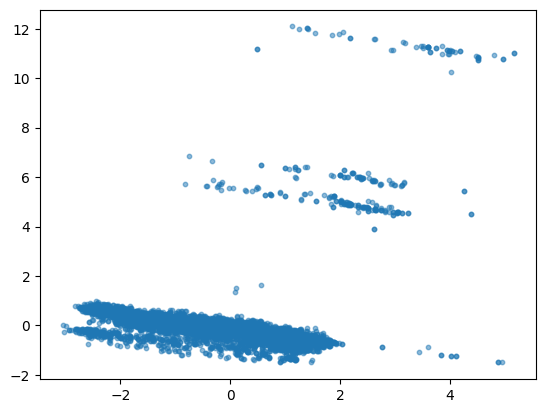

In [17]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(df[numerical_cols])

X = X[:10000]

pca = PCA()
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=10)
plt.show()

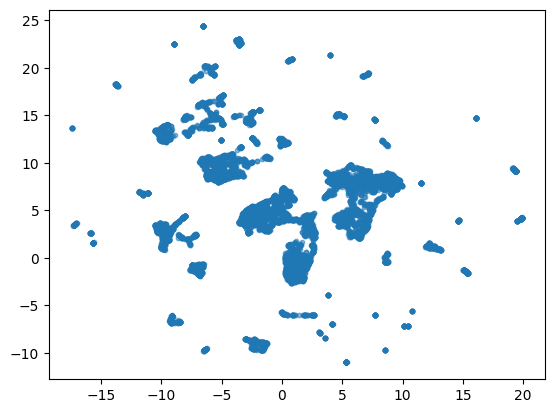

In [18]:
import umap

reducer = umap.UMAP(n_components=2)
X_umap = reducer.fit_transform(X)

plt.scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.5, s=10)
plt.show()

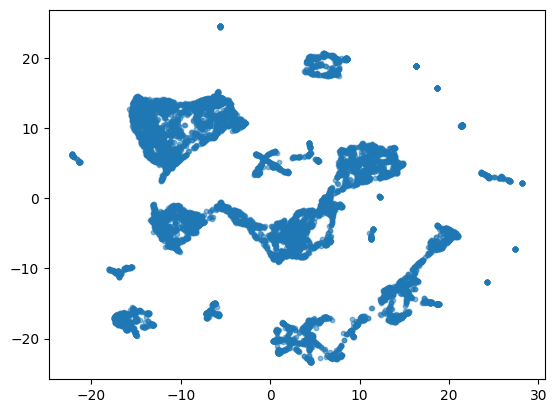

In [19]:
import pacmap

reducer = pacmap.PaCMAP()
X_pacmap = reducer.fit_transform(X)

plt.scatter(X_pacmap[:, 0], X_pacmap[:, 1], alpha=0.5, s=10)
plt.show()

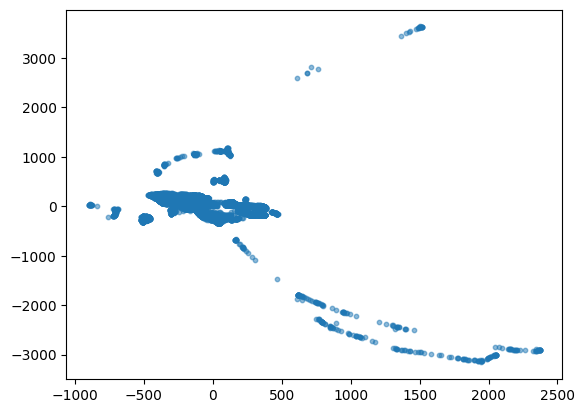

In [20]:
import trimap

reducer = trimap.TRIMAP()
X_trimap = reducer.fit_transform(X)

plt.scatter(X_trimap[:, 0], X_trimap[:, 1], alpha=0.5, s=10)
plt.show()

Will use momentum during exaggeration phase
Computing input similarities...
Using perplexity, so normalizing input data (to prevent numerical problems)
Using perplexity, not the manually set kernel width.  K (number of nearest neighbors) and sigma (bandwidth) parameters are going to be ignored.
Using ANNOY for knn search, with parameters: n_trees 50 and search_k 4500
Going to allocate memory. N: 10000, K: 90, N*K = 900000
Building Annoy tree...
Done building tree. Beginning nearest neighbor search... 
parallel (12 threads):
[===========================================================>] 99% 0.375s
Symmetrizing...
Using the given initialization.
Exaggerating Ps by 12.000000
Input similarities computed (sparsity = 0.011982)!
Learning embedding...
Using FIt-SNE approximation.
Iteration 50 (50 iterations in 0.33 seconds), cost 4.510639
Iteration 100 (50 iterations in 0.31 seconds), cost 3.878723
Iteration 150 (50 iterations in 0.31 seconds), cost 3.683904
Iteration 200 (50 iterations in 0.3

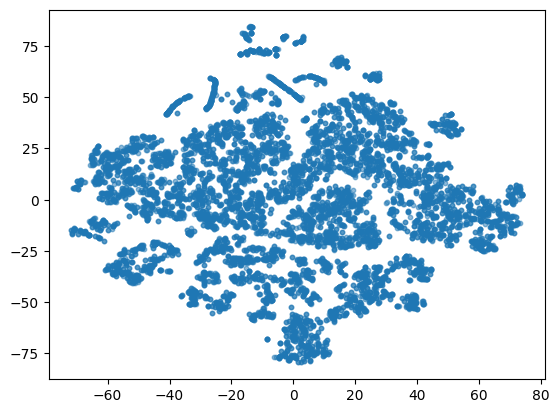

In [26]:
import fitsne
import numpy as np

X_input = np.ascontiguousarray(X, dtype=np.float64)
X_fitsne = fitsne.FItSNE(X_input)

plt.scatter(X_fitsne[:, 0], X_fitsne[:, 1], alpha=0.5, s=10)
plt.show()